In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import os
import time

# --- 設定 ---
DATASET_NAME = 'imagenette/320px-v2'
BATCH_SIZE = 128
IMG_SIZE = 128

# ===================================================
# 步驟 0: GPU 檢查與配置
# ===================================================
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # 設定 GPU 記憶體增長
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        # 設置策略
        strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")
        print(f"✅ 成功偵測到 {len(gpus)} 個 GPU！將使用第一個 GPU 進行訓練。")
        print(f"當前使用的 TensorFlow 版本: {tf.__version__}")
    except RuntimeError as e:
        print(f"❌ GPU 設定失敗: {e}")
        strategy = tf.distribute.OneDeviceStrategy(device="/cpu:0")
else:
    print("⚠️ 未偵測到 GPU。訓練將在 CPU 上運行。")
    strategy = tf.distribute.OneDeviceStrategy(device="/cpu:0")

# ===================================================
# 步驟 1: 載入資料集和資訊 (極限兼容寫法)
# ===================================================
print(f"--- 載入與檢查資料集：{DATASET_NAME} ---")

try:
    # 直接使用 tfds.load 載入所有東西
    # 這是最兼容的寫法，它會自動處理下載、生成，並返回數據和資訊。
    # 如果資料集已下載，此處會非常快。
    (ds_train_full, ds_validation_full), ds_info = tfds.load(
        DATASET_NAME,
        split=['train', 'validation'],
        as_supervised=True,
        shuffle_files=False, # 這裡不打亂，為了後續的圖片抽取
        with_info=True,
        download=True # 確保強制檢查並下載/生成
    )

except Exception as e:
    print(f"❌ 嚴重錯誤：資料集載入失敗。請檢查您的 TFDS 版本是否真的太老，或網路問題。錯誤訊息: {e}")
    # 這裡的錯誤可能是因為 tfds.load() 語法在您的版本中返回的東西結構不同
    raise

# ===================================================
# 步驟 2: 統計資料集總數與類別資訊
# ===================================================
# 這裡假設 ds_info 結構是正確的 (如果 ds_info 提取失敗，會是新的錯誤)
train_count = ds_info.splits['train'].num_examples
validation_count = ds_info.splits['validation'].num_examples
total_images = train_count + validation_count

class_names = ds_info.features['label'].names
num_classes = ds_info.features['label'].num_classes

print(f"\n----------------------------------------")
print(f"✅ 資料集資訊提取完成。")
print(f"圖片總數 (訓練集 + 驗證集): {total_images:,} 張")
print(f"訓練集總數: {train_count:,} 張")
print(f"驗證集總數: {validation_count:,} 張")
print(f"總類別數: {num_classes} 個")
print(f"類別名稱: {class_names}")
print(f"----------------------------------------")


print(f"\n✅ 變數 ds_train_full、ds_validation_full、ds_info 已定義。請繼續執行下一個區塊。")

✅ 成功偵測到 1 個 GPU！將使用第一個 GPU 進行訓練。
當前使用的 TensorFlow 版本: 2.19.0
--- 載入與檢查資料集：imagenette/320px-v2 ---

----------------------------------------
✅ 資料集資訊提取完成。
圖片總數 (訓練集 + 驗證集): 13,394 張
訓練集總數: 9,469 張
驗證集總數: 3,925 張
總類別數: 10 個
類別名稱: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
----------------------------------------

✅ 變數 ds_train_full、ds_validation_full、ds_info 已定義。請繼續執行下一個區塊。



--- 抽取並展示每類一張圖片 ---


/tmp/ipython-input-2785305151.py:36: UserWarning: Glyph 38568 (\N{CJK UNIFIED IDEOGRAPH-96A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipython-input-2785305151.py:36: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipython-input-2785305151.py:36: UserWarning: Glyph 25277 (\N{CJK UNIFIED IDEOGRAPH-62BD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipython-input-2785305151.py:36: UserWarning: Glyph 21462 (\N{CJK UNIFIED IDEOGRAPH-53D6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipython-input-2785305151.py:36: UserWarning: Glyph 20491 (\N{CJK UNIFIED IDEOGRAPH-500B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipython-input-2785305151.py:36: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  plt.

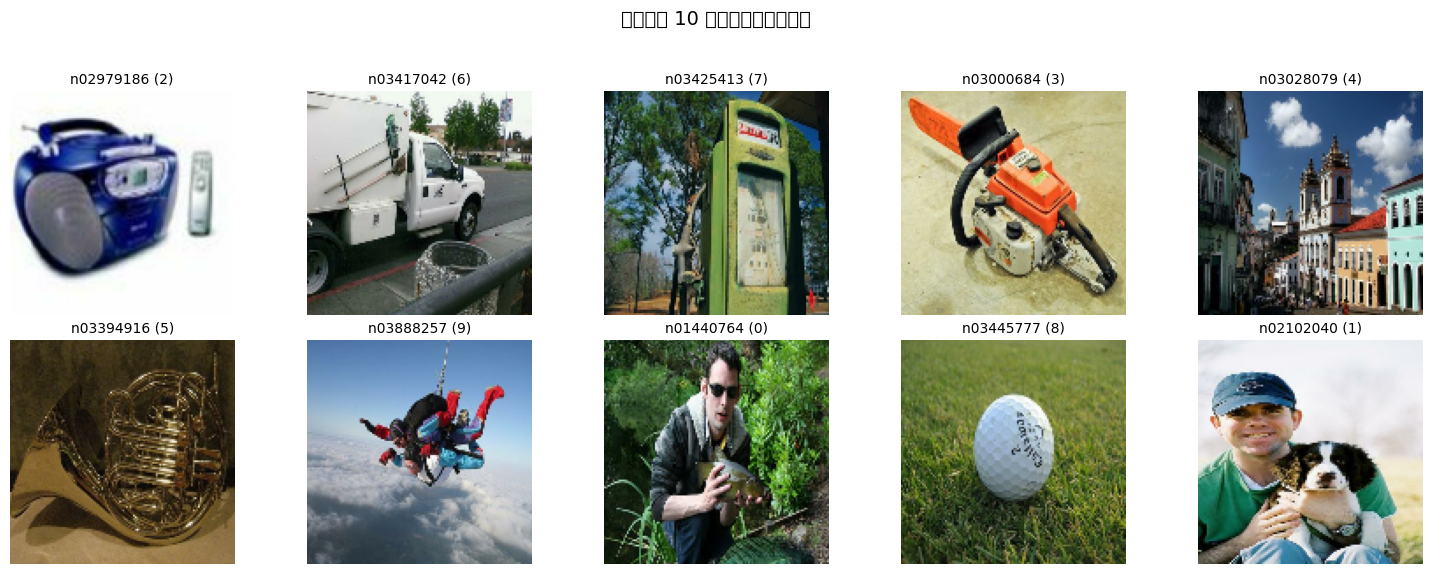


✅ 資料集已完成預處理、打亂和批次化。


In [ ]:
# 2.1 定義預處理函數
IMG_SIZE = 128
def normalize_img(image, label):
    """將圖片調整為固定大小並標準化到 [0, 1]"""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return tf.cast(image, tf.float32) / 255.0, label

# 2.2 抽取每個類別一張圖片並展示
print("\n--- 抽取並展示每類一張圖片 ---")

sampled_images = {}
for image, label in ds_train_full:
    label_int = label.numpy()
    if label_int not in sampled_images:
        # 將 Tensor 轉換為 NumPy 陣列，並進行預處理以便顯示
        normalized_image = normalize_img(image, label)[0].numpy()
        sampled_images[label_int] = normalized_image

    if len(sampled_images) == num_classes:
        break

# 繪圖
plt.figure(figsize=(15, 6))
for i, label_int in enumerate(sampled_images):
    image = sampled_images[label_int]
    class_name = class_names[label_int]

    plt.subplot(2, 5, i + 1)
    # 由於圖片已經標準化，需要乘以 255 才能正常顯示 uint8 圖片，
    # 但這裡我們顯示浮點數圖片也可以
    plt.imshow(image)
    plt.title(f"{class_name} ({label_int})", fontsize=10)
    plt.axis('off')

plt.suptitle(f"隨機抽取 {num_classes} 個類別的圖片各一張", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2.3 準備最終的訓練/驗證 Dataset
BATCH_SIZE = 32
BUFFER_SIZE = tf.data.AUTOTUNE # 自動調整

# 重新載入，並啟用 shuffle_files 確保數據集在載入時就打亂
(ds_train, ds_validation) = tfds.load(
    DATASET_NAME,
    split=['train', 'validation'],
    shuffle_files=True,
    as_supervised=True,
)

# 應用預處理、打亂、批次化和預取
ds_train = ds_train.map(normalize_img, num_parallel_calls=BUFFER_SIZE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(buffer_size=1000) # 在緩衝區內打亂
ds_train = ds_train.batch(BATCH_SIZE)
ds_train = ds_train.prefetch(BUFFER_SIZE)

ds_validation = ds_validation.map(normalize_img, num_parallel_calls=BUFFER_SIZE)
ds_validation = ds_validation.batch(BATCH_SIZE)
ds_validation = ds_validation.prefetch(BUFFER_SIZE)

print(f"\n✅ 資料集已完成預處理、打亂和批次化。")

--- 正在統計類別分布，請稍候 ---


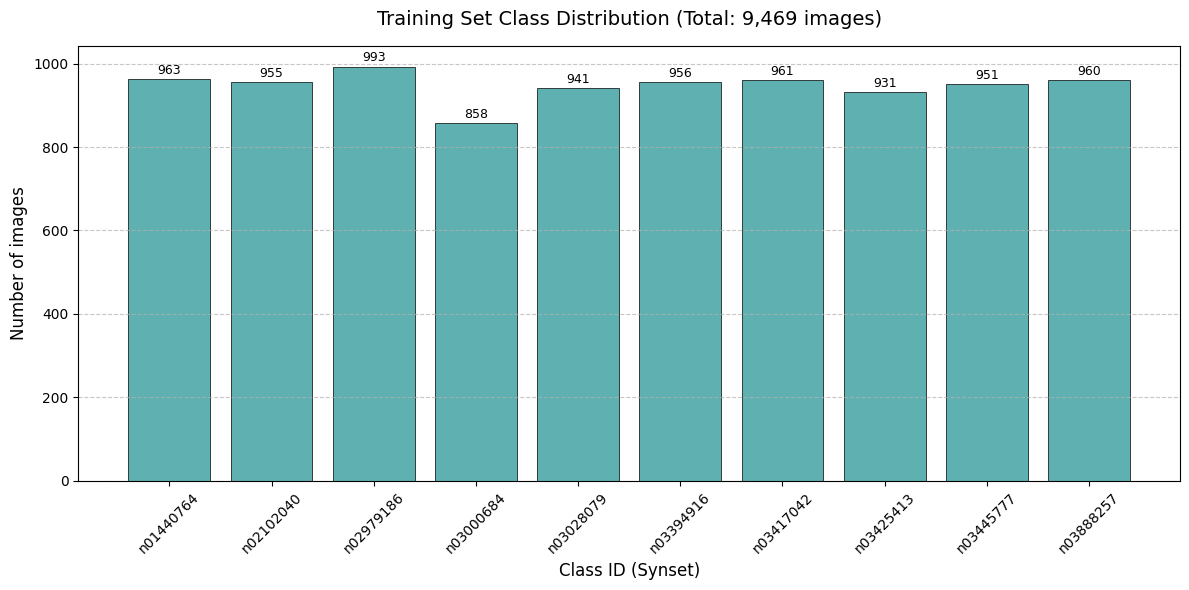

✅ 類別分布圖表已生成。總計: 9469 張圖片，每類約 946 張。


In [ ]:
import matplotlib.pyplot as plt
import collections

# 1. 統計訓練集中的類別分布
print("--- 正在統計類別分布，請稍候 ---")
label_counts = collections.Counter()
for _, label in ds_train_full:
    label_counts[label.numpy()] += 1

# 2. 準備繪圖數據
# 獲取類別名稱（如 n01440764...）
labels = [ds_info.features['label'].int2str(i) for i in range(num_classes)]
counts = [label_counts[i] for i in range(num_classes)]
total_images = sum(counts)

# 3. 繪製圖表
plt.figure(figsize=(12, 6))
# 使用青色 (Teal) 匹配您的截圖風格
bars = plt.bar(labels, counts, color='#5fb0b0', edgecolor='black', linewidth=0.5)

# 在柱狀圖上方顯示具體數值
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom', fontsize=9)

# 設定標題與標籤
plt.title(f"Training Set Class Distribution (Total: {total_images:,} images)", fontsize=14, pad=15)
plt.xlabel("Class ID (Synset)", fontsize=12)
plt.ylabel("Number of images", fontsize=12)

# 美化 X 軸標籤（旋轉角度避免重疊）
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"✅ 類別分布圖表已生成。總計: {total_images} 張圖片，每類約 {total_images//10} 張。")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 專業級數據處理
# ==========================================
def preprocess_for_mobilenet(image, label):
    # MobileNetV2 預期輸入為 [-1, 1] 之間，或使用其專用預處理函數
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# 數據增強 (讓模型更強壯)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

# 重新構建 Dataset
ds_train_final = ds_train_full.map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
ds_train_final = ds_train_final.cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

ds_val_final = ds_validation_full.map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
ds_val_final = ds_val_final.batch(32).prefetch(tf.data.AUTOTUNE)

# ==========================================
# 2. 搭建遷移學習模型 (這就是 98% 的秘密)
# ==========================================
with tf.device('/gpu:0'):
    # A. 載入預訓練模型 (不包含最後的分類層)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # B. 凍結基礎模型 (先不改動 Google 訓練好的特徵提取能力)
    base_model.trainable = False

    # C. 組合新模型
    model = tf.keras.Sequential([
        data_augmentation,           # 訓練時才啟用的數據增強
        base_model,                  # 大師級特徵提取器
        tf.keras.layers.GlobalAveragePooling2D(), # 將特徵轉為向量
        tf.keras.layers.Dropout(0.2), # 防死背
        tf.keras.layers.Dense(num_classes, activation='softmax') # 最後的分類決策
    ])

    # D. 編譯 (遷移學習通常用較慢的學習率)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

# ==========================================
# 3. 開始訓練
# ==========================================
print("\n--- 🌟 遷移學習啟動 (MobileNetV2) ---")
# 遷移學習收斂極快，通常 10 週期就能達到極高準確度
history = model.fit(
    ds_train_final,
    validation_data=ds_val_final,
    epochs=15
)

# ==========================================
# 4. 分析結果 (不需手動畫圖，直接看文字輸出或呼叫之前的 plot 函數)
# ==========================================
final_val_acc = max(history.history['val_accuracy'])
print(f"\n✅ 訓練完成！最高驗證集準確率：{final_val_acc:.4f}")


--- 🌟 遷移學習啟動 (MobileNetV2) ---
Epoch 1/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.3054 - loss: 2.1869 - val_accuracy: 0.8724 - val_loss: 0.6415
Epoch 2/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.8089 - loss: 0.7041 - val_accuracy: 0.9378 - val_loss: 0.3084
Epoch 3/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.8827 - loss: 0.4225 - val_accuracy: 0.9521 - val_loss: 0.2114
Epoch 4/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9008 - loss: 0.3394 - val_accuracy: 0.9575 - val_loss: 0.1692
Epoch 5/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9122 - loss: 0.2896 - val_accuracy: 0.9597 - val_loss: 0.1465
Epoch 6/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9256 - loss: 0.2465 - val_accuracy: 0.9651 - val_loss: 0.1286
Epoch 7/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9340 - loss: 0.2200 - val_accuracy: 0.9679 - val_loss: 0.1179
Epoch 8/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - ac


--- 📊 訓練結果分析 ---
最低驗證損失 (Min Validation Loss): 0.0872
模型達到最低驗證損失的**最佳時間 (Best Epoch)** 是第 14 週期。


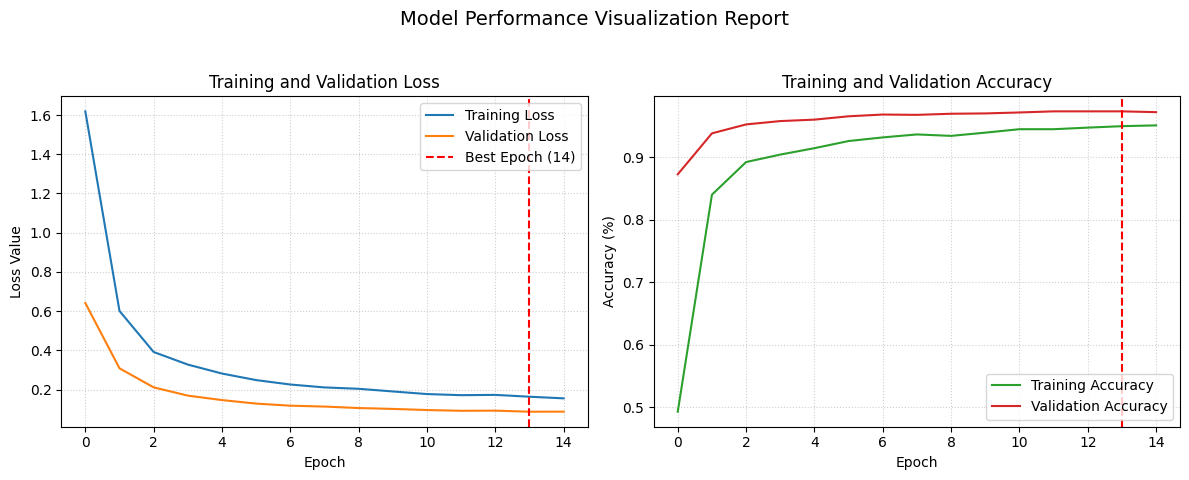

✅ 已成功生成視覺化圖表：training_history_report.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 4.1 找出最佳時間 (以驗證集 Loss 最低為準)
# ==========================================
# 從訓練紀錄中提取驗證損失
val_loss_list = history.history['val_loss']
min_val_loss = min(val_loss_list)
# 找出最小值所在的索引並 +1 (因為週期從 1 開始計算)
best_epoch = np.argmin(val_loss_list) + 1

print(f"\n--- 📊 訓練結果分析 ---")
print(f"最低驗證損失 (Min Validation Loss): {min_val_loss:.4f}")
print(f"模型達到最低驗證損失的**最佳時間 (Best Epoch)** 是第 {best_epoch} 週期。")

# ==========================================
# 4.2 繪製 Accuracy 和 Loss 曲線圖
# ==========================================
def plot_history(history, filename='training_history_report.png'):
    """依照模板繪製訓練過程中的 Accuracy 和 Loss 曲線圖。"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    # 設定畫布大小
    plt.figure(figsize=(12, 5))

    # --- 左圖：繪製 Loss 曲線 ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e')
    # 畫出最佳週期的垂直紅虛線
    plt.axvline(x=best_epoch - 1, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    # --- 右圖：繪製 Accuracy 曲線 ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#2ca02c')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#d62728')
    # 畫出最佳週期的垂直紅虛線
    plt.axvline(x=best_epoch - 1, color='r', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)

    # 整體圖表美化
    plt.suptitle("Model Performance Visualization Report", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # 儲存並顯示圖表
    plt.savefig(filename)
    plt.show()

# 執行繪圖函數
plot_history(history)
print(f"✅ 已成功生成視覺化圖表：training_history_report.png")